In [1]:
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

# Generate 5 years of monthly data
dates = pd.date_range("2021-01-01", periods=60, freq="MS")

# Create a time series
trend = np.linspace(100, 180, len(dates))
seasonality = 15 * np.sin(2 * np.pi * np.arange(len(dates)) / 12)
noise = np.random.normal(0, 5, len(dates))

values = trend + seasonality + noise

# DataFrame
df = pd.DataFrame({
    "date": dates,
    "value": values
})

print(df.head())

        date       value
0 2021-01-01  102.483571
1 2021-02-01  108.164611
2 2021-03-01  118.940688
3 2021-04-01  126.682946
4 2021-05-01  117.243343


c:\Users\aline\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
23:18:08 - cmdstanpy - INFO - Chain [1] start processing
23:18:08 - cmdstanpy - INFO - Chain [1] done processing


            ds        yhat  yhat_lower  yhat_upper
115 2030-08-01  255.791006  249.309474  262.096546
116 2030-09-01  249.423694  242.604355  256.065129
117 2030-10-01  245.934388  239.312386  252.401922
118 2030-11-01  253.365188  246.503294  259.895287
119 2030-12-01  255.413970  248.355643  262.116266


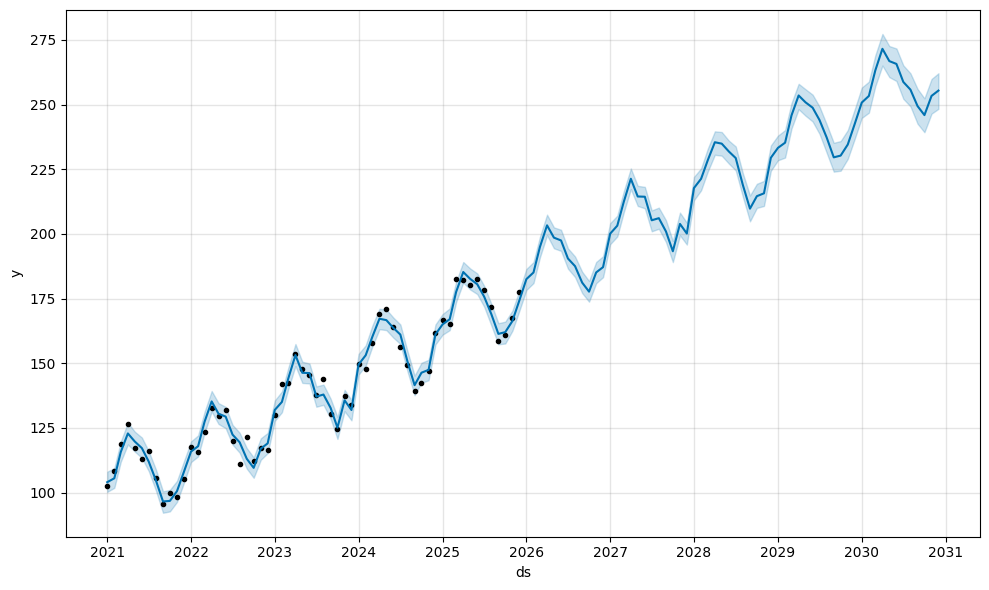

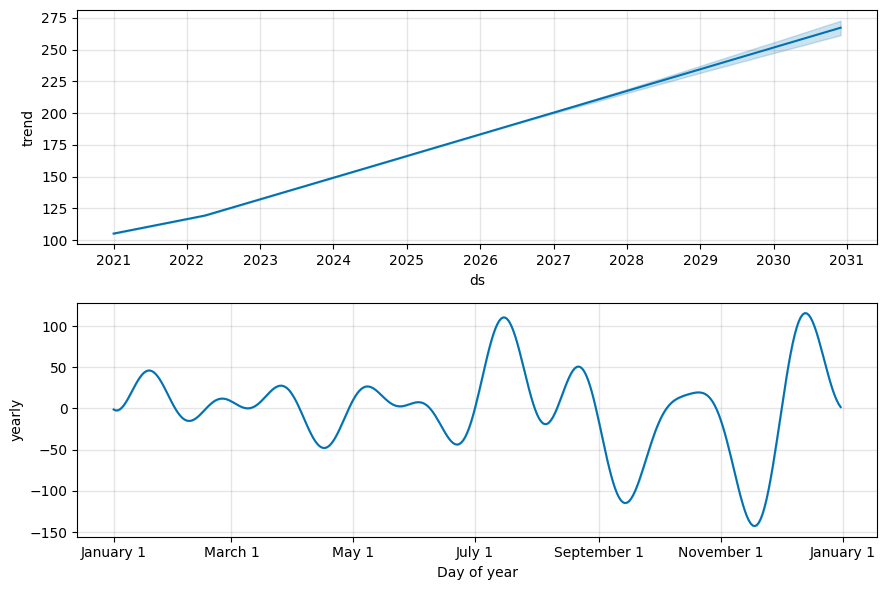

In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Example dataframe
# df = pd.read_csv("data.csv")

# Prophet requires columns named ds and y
prophet_df = df.rename(columns={
    "date": "ds",
    "value": "y"
})

# Ensure datetime format
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

# Create model
model = Prophet()

# Train
model.fit(prophet_df)

# Forecast next 12 periods
future = model.make_future_dataframe(
    periods=60,
    freq="MS"      # Monthly Start. Use "D" for daily, "W" for weekly, etc.
)

forecast = model.predict(future)

# View forecast
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())

# Plot
fig = model.plot(forecast)
plt.show()

# Plot trend/seasonality
fig2 = model.plot_components(forecast)
plt.show()